# Assignment 2

![Assignment 2](assets/assn2.png)

In [42]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import math

In [ ]:
img = cv2.imread('../../../assets/histogram.jpg', cv2.IMREAD_GRAYSCALE)

In [44]:
def get_hist_pdf_cdf(img):
    L = 256
    h, w = img.shape
    size = h * w
    hist = cv2.calcHist([img], [0], None, [L], [0, L])
    hist = cv2.transpose(hist)[0]
    pdf = hist / size
    cdf = np.zeros(L)
    cdf[0] = pdf[0]
    for i in range(1, L):
        cdf[i] = cdf[i-1] + pdf[i]
    return hist, pdf, cdf

In [45]:
def erlang_pdf(x, k, mu):
    assert k > 0 and mu > 0, "k must be positive integer and mu must be positive float"
    pdf = (x**(k-1)) * np.exp(-x/mu) / (mu**k * math.factorial(k-1))
    if(math.isnan(pdf) or math.isinf(pdf)):
        pdf = 0
    return pdf

In [46]:
def target_histogram(k, mu):
    assert k > 0 and mu > 0, "k must be positive integer and mu must be positive float"
    L = 256
    mx = max(20, int(2 * k * mu))
    hist = np.zeros(L, dtype=np.float64)
    for i in range(L):
        x = (i * mx) / (L - 1)
        hist[i] = erlang_pdf(x, k, mu)
    hist = hist / np.sum(hist)
    hist = hist * (img.shape[0] * img.shape[1])
    pdf = hist / np.sum(hist)
    cdf = np.zeros(L)
    cdf[0] = pdf[0]
    for i in range(1, L):
        cdf[i] = cdf[i-1] + pdf[i]
    return hist, pdf, cdf

In [47]:
def histogram_matching(source, target_cdf):
    L = 256
    _, _, src_cdf = get_hist_pdf_cdf(source)
    src_cdf_t = np.round(src_cdf * (L - 1)).astype(np.uint8)
    target_cdf_t = np.round(target_cdf * (L - 1)).astype(np.uint8)
    mapping = np.zeros(L, dtype=np.uint8)
    for i in range(L):
        src = src_cdf_t[i]
        diff = np.abs(target_cdf_t - src)
        mapping[i] = np.argmin(diff)
    matched = cv2.LUT(source, mapping)
    return matched, mapping

In [48]:
k = int(input("Enter Erlang shape parameter (k, integer > 0): "))
mu = float(input("Enter Erlang scale parameter (mu, float > 0): "))

L = 256
x = np.arange(L)

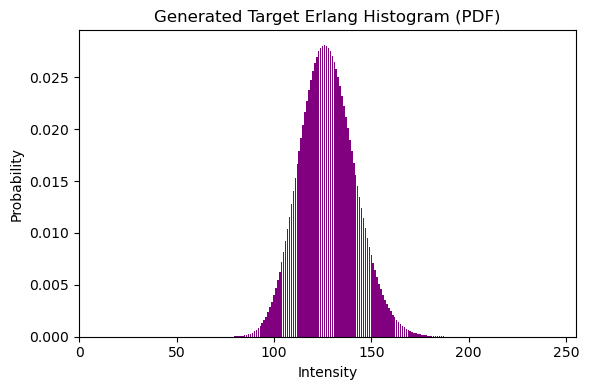

In [49]:
target_hist, target_pdf, target_cdf = target_histogram(k, mu)

plt.figure(figsize=(6,4))
plt.title("Generated Target Erlang Histogram (PDF)")
plt.bar(x, target_pdf, color='purple')
plt.xlabel("Intensity")
plt.ylabel("Probability")
plt.xlim([0,255])
plt.tight_layout()
plt.show()

In [50]:
img_matched, mapping = histogram_matching(img, target_cdf)

hist_in, pdf_in, cdf_in = get_hist_pdf_cdf(img)
hist_out, pdf_out, cdf_out = get_hist_pdf_cdf(img_matched)

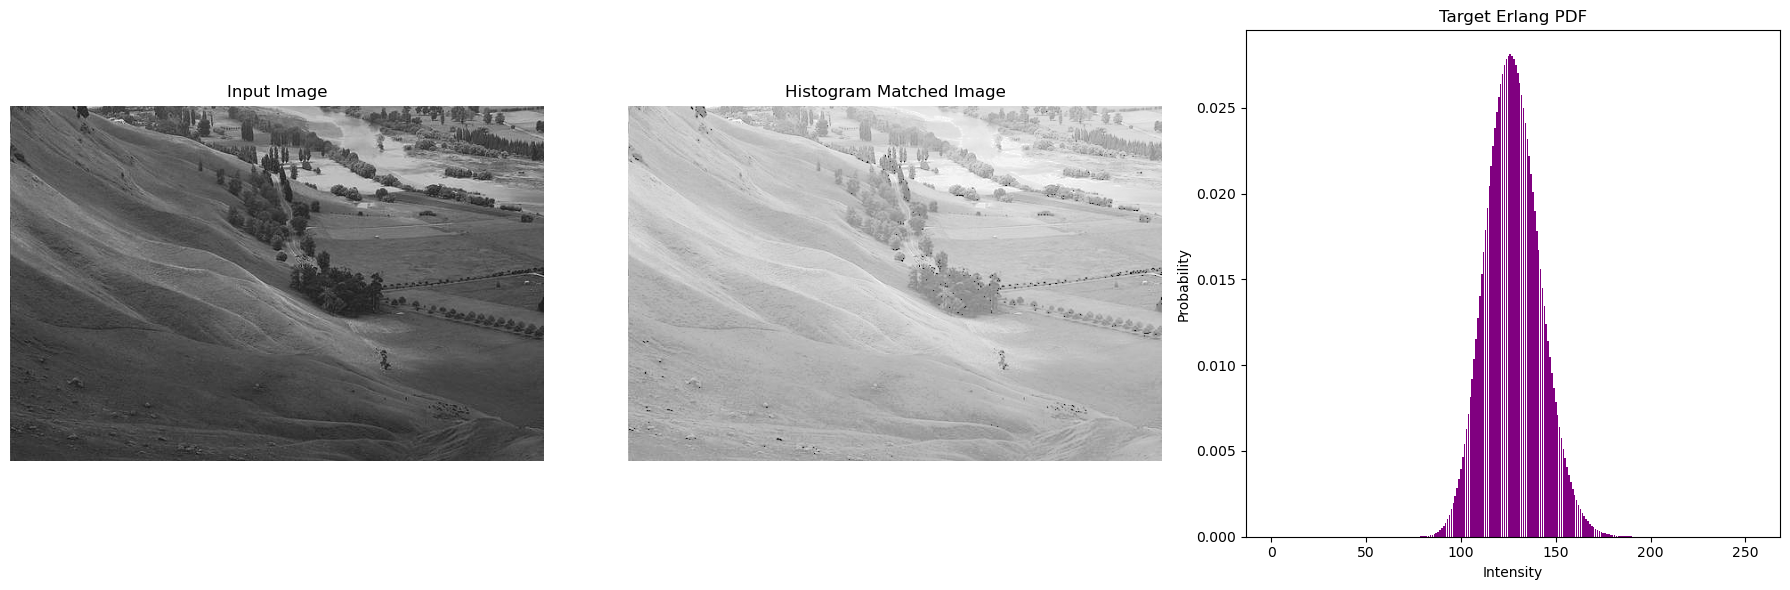

In [51]:
plt.figure(figsize=(18, 6))

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title("Input Image")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(img_matched, cmap='gray')
plt.title("Histogram Matched Image")
plt.axis('off')

plt.subplot(1,3,3)
plt.bar(x, target_pdf, color='purple')
plt.title("Target Erlang PDF")
plt.xlabel("Intensity")
plt.ylabel("Probability")

plt.tight_layout()
plt.show()

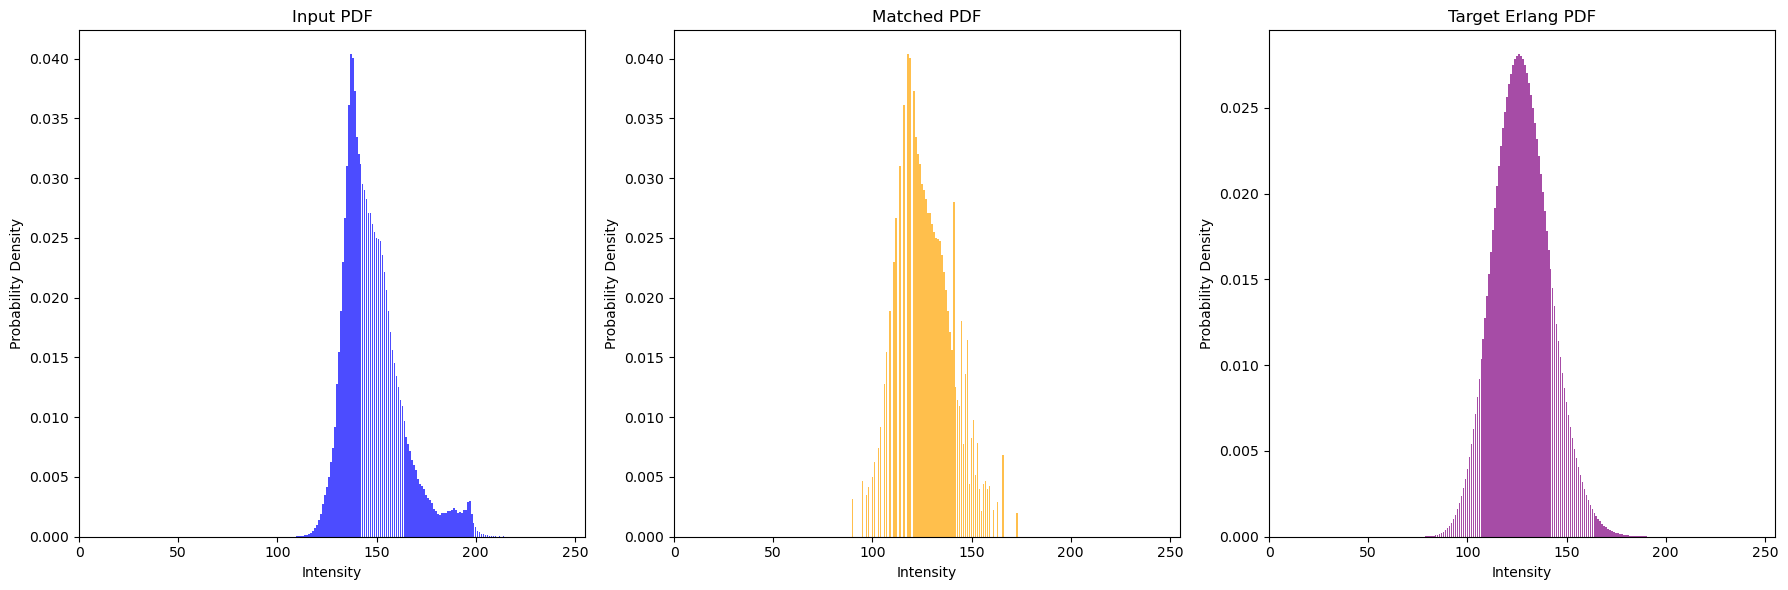

In [52]:
plt.figure(figsize=(18, 6))

plt.subplot(1,3,1)
plt.title("Input PDF")
plt.bar(x, pdf_in, color='blue', alpha=0.7)
plt.xlim([0,255])
plt.xlabel("Intensity")
plt.ylabel("Probability Density")

plt.subplot(1,3,2)
plt.title("Matched PDF")
plt.bar(x, pdf_out, color='orange', alpha=0.7)
plt.xlim([0,255])
plt.xlabel("Intensity")
plt.ylabel("Probability Density")

plt.subplot(1,3,3)
plt.title("Target Erlang PDF")
plt.bar(x, target_pdf, color='purple', alpha=0.7)
plt.xlim([0,255])
plt.xlabel("Intensity")
plt.ylabel("Probability Density")

plt.tight_layout()
plt.show()

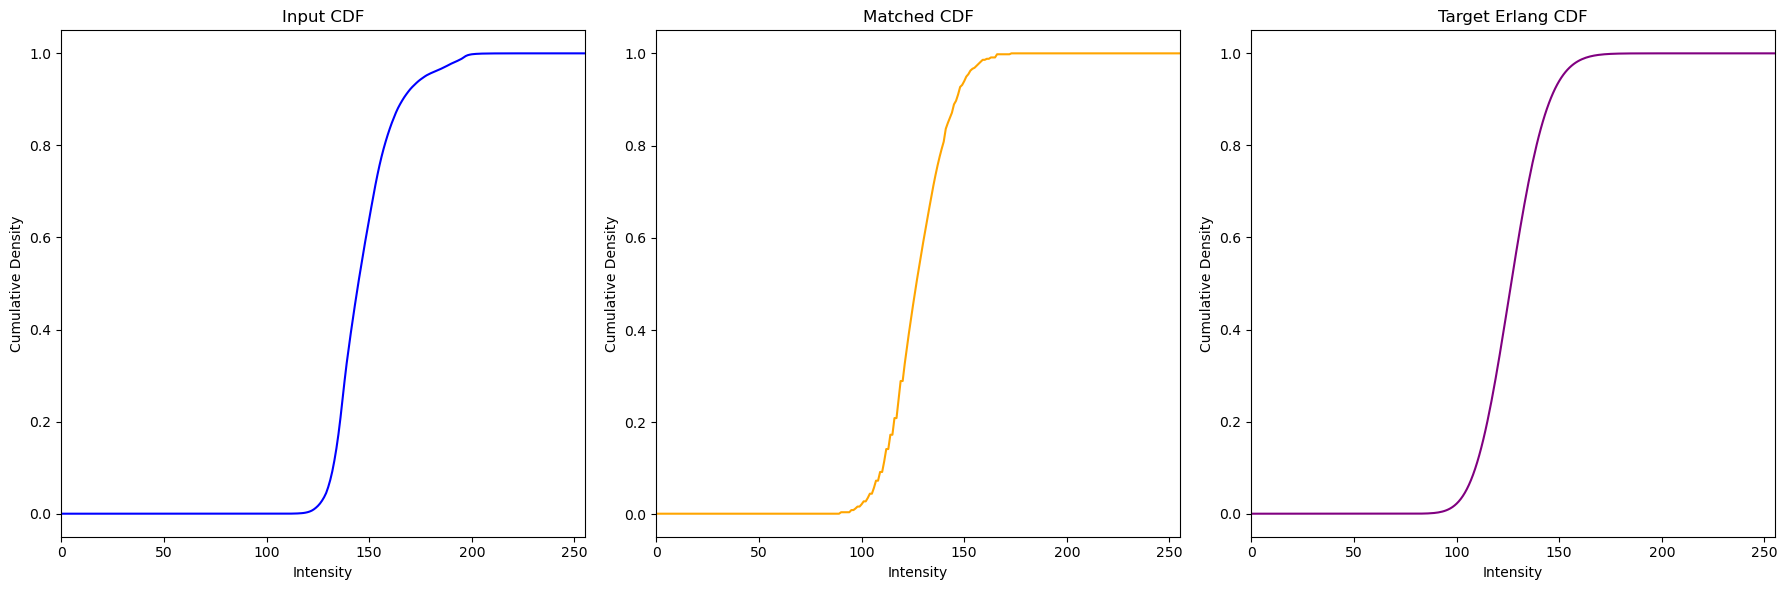

In [53]:
plt.figure(figsize=(18, 6))

plt.subplot(1,3,1)
plt.title("Input CDF")
plt.plot(x, cdf_in, color='blue')
plt.xlim([0,255])
plt.xlabel("Intensity")
plt.ylabel("Cumulative Density")

plt.subplot(1,3,2)
plt.title("Matched CDF")
plt.plot(x, cdf_out, color='orange')
plt.xlim([0,255])
plt.xlabel("Intensity")
plt.ylabel("Cumulative Density")

plt.subplot(1,3,3)
plt.title("Target Erlang CDF")
plt.plot(x, target_cdf, color='purple')
plt.xlim([0,255])
plt.xlabel("Intensity")
plt.ylabel("Cumulative Density")

plt.tight_layout()
plt.show()

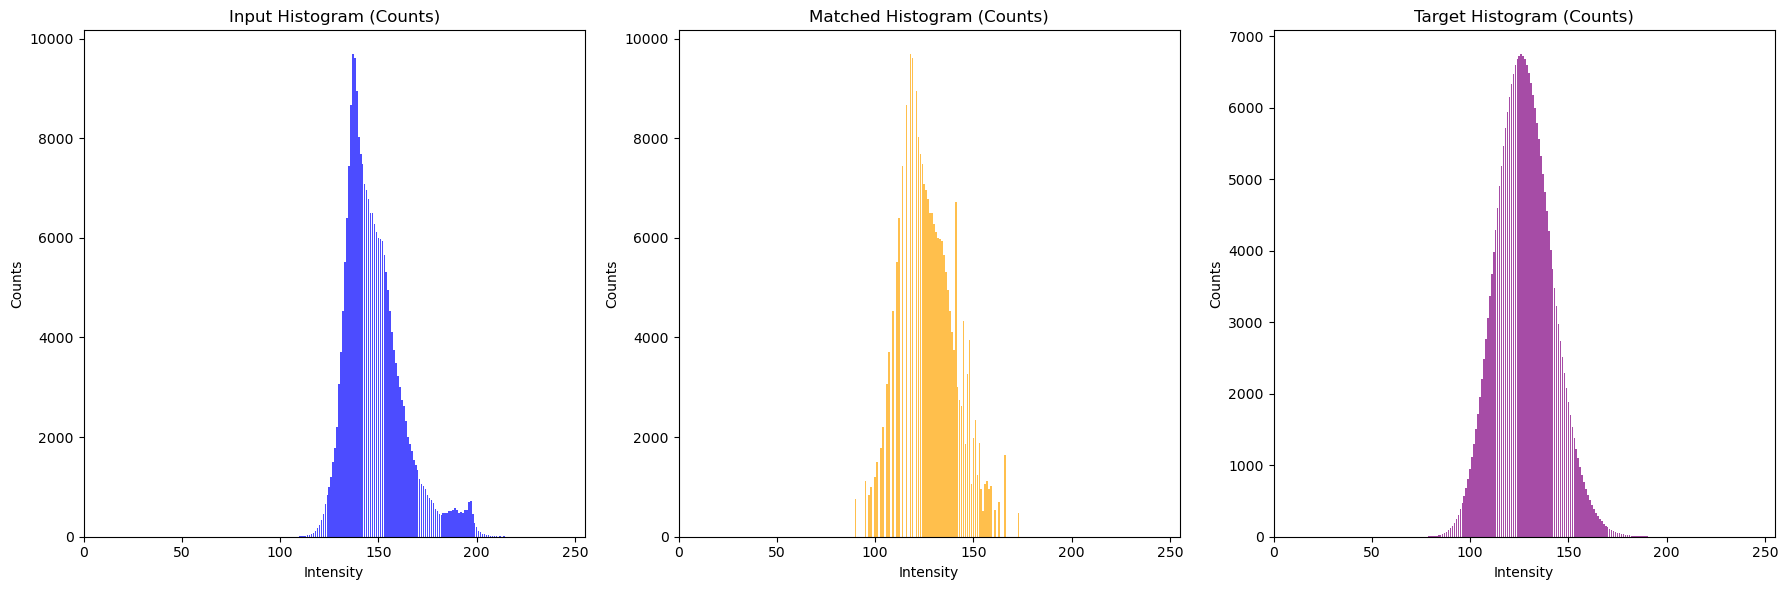

In [54]:
plt.figure(figsize=(18, 6))

plt.subplot(1,3,1)
plt.title("Input Histogram (Counts)")
plt.bar(x, hist_in, color='blue', alpha=0.7)
plt.xlim([0,255])
plt.xlabel("Intensity")
plt.ylabel("Counts")

plt.subplot(1,3,2)
plt.title("Matched Histogram (Counts)")
plt.bar(x, hist_out, color='orange', alpha=0.7)
plt.xlim([0,255])
plt.xlabel("Intensity")
plt.ylabel("Counts")

plt.subplot(1,3,3)
plt.title("Target Histogram (Counts)")
plt.bar(x, target_hist, color='purple', alpha=0.7)
plt.xlim([0,255])
plt.xlabel("Intensity")
plt.ylabel("Counts")

plt.tight_layout()
plt.show()